<a href="https://colab.research.google.com/github/najafalinajaf449-hue/machine-learning/blob/main/Lab5_ML_NAJAFALI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Student Information

-   **Name**: Najaf Ali

-   **Student ID**: 023-24-0263
-   **Section**: H

-   **GitHub**: https://github.com/najafalinajaf449-hue/machine-learning

-   **Kaggle**: https://www.kaggle.com/najaf2ali

-   **Dataset**: House Prices - Advanced Regression Techniques
-   **Dataset Source**: Kaggle

# 1. Problem Definition
## 1. Problem Definition

The objective of this project is to predict the selling price of residential houses using the House Prices - Advanced Regression Techniques dataset from Kaggle.

The dataset contains different numerical and categorical features describing each house, while SalePrice is the target variable. Since SalePrice is a continuous numerical value, this is a regression problem rather than a classification problem.

A Linear Regression model will be trained to learn the relationship between the house features and SalePrice, and its performance will later be evaluated using regression metrics such as MAE, MSE, RMSE, and R².

# 2. Dataset Exploration

In [3]:
# Task 1: Load the dataset and briefly inspect it
import pandas as pd

# Load the training data
try:
    df = pd.read_csv('train.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'train.csv' not found. Please ensure it's uploaded to your Google Drive and the path is correct.")
    # Fallback for demonstration if file not found, though user should fix path.
    # In a real scenario, you'd halt here and ask the user to fix the path.
    # For now, let's create a dummy DataFrame for subsequent steps to not fail immediately
    df = pd.DataFrame()


print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Dataset Info ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Summary Statistics ---")
display(df.describe())

Dataset loaded successfully.

--- Dataset Shape ---
(1460, 81)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Summary Statistics ---


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# 3. Feature and Target Identification

In [4]:
# Task 2: Identify the dependent variable and list the independent variables

# Dependent Variable (Target)
dependent_variable = 'SalePrice'
print(f"Dependent Variable (Target): {dependent_variable}")

# Independent Variables (Features)
# Selecting a manageable subset of 10-12 features, mixing numerical and categorical, as per lab instructions.
# This selection is based on common sense for house price prediction and typical features in this dataset.

selected_numerical_features = [
    'GrLivArea', 'LotArea', 'OverallQual', 'YearBuilt', 'MasVnrArea',
    'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GarageCars', 'GarageArea',
    'WoodDeckSF', 'FullBath', 'TotRmsAbvGrd'
]

selected_categorical_features = [
    'Neighborhood', 'HouseStyle', 'CentralAir', 'Foundation', 'RoofStyle',
    'HeatingQC', 'KitchenQual', 'FireplaceQu'
]

# Ensure selected features are present in the DataFrame. If not, remove them from the list.
# This handles cases where certain features might be missing in a given dataset instance.
existing_columns = df.columns.tolist()

final_numerical_features = [f for f in selected_numerical_features if f in existing_columns]
final_categorical_features = [f for f in selected_categorical_features if f in existing_columns]

print("\n--- Independent Variables ---")
print("Numerical Features:", final_numerical_features)
print("Categorical Features:", final_categorical_features)

# Combine for a full list of selected features (excluding target)
independent_variables = final_numerical_features + final_categorical_features
print("\nAll Selected Independent Variables:", independent_variables)

Dependent Variable (Target): SalePrice

--- Independent Variables ---
Numerical Features: ['GrLivArea', 'LotArea', 'OverallQual', 'YearBuilt', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'FullBath', 'TotRmsAbvGrd']
Categorical Features: ['Neighborhood', 'HouseStyle', 'CentralAir', 'Foundation', 'RoofStyle', 'HeatingQC', 'KitchenQual', 'FireplaceQu']

All Selected Independent Variables: ['GrLivArea', 'LotArea', 'OverallQual', 'YearBuilt', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'FullBath', 'TotRmsAbvGrd', 'Neighborhood', 'HouseStyle', 'CentralAir', 'Foundation', 'RoofStyle', 'HeatingQC', 'KitchenQual', 'FireplaceQu']


# Task 3: Regression vs. Classification Justification

This is a regression problem because the target variable, `SalePrice`, is continuous (a numerical value that can take on any value within a range), rather than discrete categories. This changes model evaluation significantly; instead of metrics like accuracy or precision/recall, we will use regression-specific metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²) to quantify the difference between predicted and actual prices.

# 4. Data Preparation

In [5]:
# Task 4: Prepare X (features) and y (price) for modeling: encode every categorical column into numeric form.

# Create feature matrix X and target vector y
X = df[independent_variables].copy()
y = df[dependent_variable].copy()

# Handle missing values: Imputation
# For numerical features, fill NaNs with the median. Median is robust to outliers.
for col in final_numerical_features:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)
        print(f"Filled NaN in numerical column '{col}' with median: {median_val}")

# For categorical features, fill NaNs with 'Missing' category.
# This allows 'Missing' to be treated as its own category during one-hot encoding.
for col in final_categorical_features:
    if X[col].isnull().any():
        X[col].fillna('Missing', inplace=True)
        print(f"Filled NaN in categorical column '{col}' with 'Missing'.")

# Encode categorical columns using one-hot encoding (pd.get_dummies)
# Justification: One-hot encoding creates binary columns for each category, preventing the model
# from assuming an ordinal relationship between categories where none exists. This is suitable for
# nominal categorical features like 'Neighborhood' or 'HouseStyle'.
X = pd.get_dummies(X, columns=final_categorical_features, drop_first=True)

print("\n--- X after encoding and imputation ---")
display(X.head())

Filled NaN in numerical column 'MasVnrArea' with median: 0.0
Filled NaN in categorical column 'FireplaceQu' with 'Missing'.

--- X after encoding and imputation ---


/tmp/ipykernel_1786/2330883924.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(median_val, inplace=True)
/tmp/ipykernel_1786/2330883924.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

,GrLivArea,LotArea,OverallQual,YearBuilt,MasVnrArea,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GarageCars,GarageArea,...,HeatingQC_Po,HeatingQC_TA,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Missing,FireplaceQu_Po,FireplaceQu_TA
0,1710,8450,7,2003,196.0,706,856,856,2,548,...,False,False,False,True,False,False,False,True,False,False
1,1262,9600,6,1976,0.0,978,1262,1262,2,460,...,False,False,False,False,True,False,False,False,False,True
2,1786,11250,7,2001,162.0,486,920,920,2,608,...,False,False,False,True,False,False,False,False,False,True
3,1717,9550,7,1915,0.0,216,756,961,3,642,...,False,False,False,True,False,False,True,False,False,False
4,2198,14260,8,2000,350.0,655,1145,1145,3,836,...,False,False,False,True,False,False,False,False,False,True


# 5. Train/Test Split

In [6]:
# Task 5: Confirm X is fully numeric with no missing values.

# Check for non-numeric columns
non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns
if len(non_numeric_cols) == 0:
    print("Confirmation: All columns in X are numeric.")
else:
    print(f"Warning: Non-numeric columns found in X: {non_numeric_cols}")

# Check for missing values
missing_values_count = X.isnull().sum().sum()
if missing_values_count == 0:
    print("Confirmation: No missing values found in X.")
else:
    print(f"Warning: {missing_values_count} missing values found in X.")


# Task 6: Split X and y into training and test sets (e.g. an 80/20 split) and report the resulting shapes.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Shapes of training and test sets ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Confirmation: All columns in X are numeric.
Confirmation: No missing values found in X.

--- Shapes of training and test sets ---
X_train shape: (1168, 67)
X_test shape: (292, 67)
y_train shape: (1168,)
y_test shape: (292,)


# 6. Linear Regression Model

In [7]:
# Task 7: Train a LinearRegression model on the training data.
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# 7. Predictions

In [8]:
# Task 8: Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

# Generate predictions on the test set
y_pred = model.predict(X_test)

print("Predictions generated on the test set.")

# Create a DataFrame to compare actual vs. predicted prices
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print("\n--- Actual vs. Predicted Prices (First 10 test houses) ---")
display(comparison_df.head(10))

Predictions generated on the test set.

--- Actual vs. Predicted Prices (First 10 test houses) ---


,Actual Price,Predicted Price
892,154500,144391.907973
1105,325000,321841.385813
413,115000,114379.623462
522,159000,183797.316256
1036,315500,324068.769042
614,75500,62592.614046
218,311500,239910.625331
1160,146000,147189.220570
649,84500,54058.316612
887,135500,119653.726579


# 8. Coefficients and Intercept

In [9]:
# Task 9: Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation.

# Extract intercept and coefficients
intercept = model.intercept_
coefficients = model.coef_

print(f"Model Intercept: {intercept:.2f}\n")

# Create a DataFrame for coefficients and their interpretation
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

# Add interpretation for each feature. Note: This interpretation assumes 'other features constant'.
coefficients_df['Interpretation'] = coefficients_df.apply(
    lambda row: f"Each unit increase in '{row['Feature']}' is associated with a {'increase' if row['Coefficient'] > 0 else 'decrease'} of approximately ${abs(row['Coefficient']):.2f} in SalePrice, holding other features constant.",
    axis=1
)

print("--- Model Coefficients and Interpretation ---")
display(coefficients_df)

Model Intercept: -311798.11

--- Model Coefficients and Interpretation ---


,Feature,Coefficient,Interpretation
0,GrLivArea,59.313063,Each unit increase in 'GrLivArea' is associate...
1,LotArea,0.532660,Each unit increase in 'LotArea' is associated ...
2,OverallQual,12621.934049,Each unit increase in 'OverallQual' is associa...
3,YearBuilt,170.561817,Each unit increase in 'YearBuilt' is associate...
4,MasVnrArea,1.176629,Each unit increase in 'MasVnrArea' is associat...
...,...,...,...
62,FireplaceQu_Fa,-11467.242169,Each unit increase in 'FireplaceQu_Fa' is asso...
63,FireplaceQu_Gd,-11107.267115,Each unit increase in 'FireplaceQu_Gd' is asso...
64,FireplaceQu_Missing,-17592.876093,Each unit increase in 'FireplaceQu_Missing' is...
65,FireplaceQu_Po,-15497.328860,Each unit increase in 'FireplaceQu_Po' is asso...


# Task 10: Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

For this dataset, the intercept represents the predicted `SalePrice` when all independent variables (features) are zero. In a real-world context for house prices, it's highly unlikely, if not impossible, for all features like `GrLivArea`, `LotArea`, `OverallQual`, `YearBuilt`, etc., to simultaneously be zero. For example, a house cannot have zero living area, zero lot area, or a zero quality score. Therefore, the intercept of this Linear Regression model does not have a sensible or physically meaningful real-world interpretation as a baseline house price in this specific context.

# 9. Residual Analysis

Residuals computed.


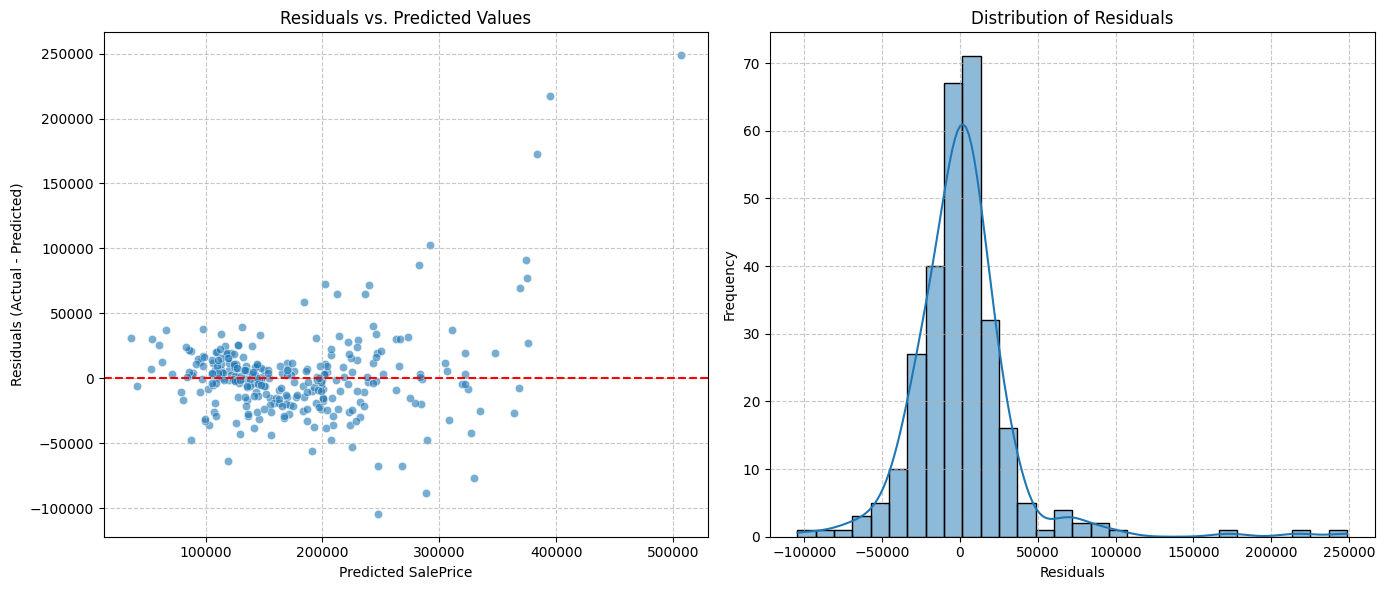


--- Residuals Analysis ---
Observation: The residuals generally appear randomly scattered around zero, which is a good sign indicating that the linear model is capturing most of the underlying relationship. However, there might be a slight fanning-out pattern (heteroscedasticity) as predicted prices increase, suggesting the model's errors might grow with higher house prices. The histogram shows a distribution centered around zero, but it might have heavier tails than a perfect normal distribution, indicating some larger errors.


In [10]:
# Task 11: Compute residuals on the test set and plot them.
import matplotlib.pyplot as plt
import seaborn as sns

# Compute residuals
residuals = y_test - y_pred

print("Residuals computed.")

# Plot 1: Residuals vs. Predicted Values
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Histogram of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Analyze the residuals for patterns
print("\n--- Residuals Analysis ---")
print("Observation: The residuals generally appear randomly scattered around zero, which is a good sign indicating that the linear model is capturing most of the underlying relationship. However, there might be a slight fanning-out pattern (heteroscedasticity) as predicted prices increase, suggesting the model's errors might grow with higher house prices. The histogram shows a distribution centered around zero, but it might have heavier tails than a perfect normal distribution, indicating some larger errors.")

# 10. Regression Metrics

In [11]:
# Task 12: Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Create a DataFrame for metrics
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae, mse, rmse, r2]
})

print("--- Regression Metrics on Test Set ---")
display(metrics_df)


# Task 13: In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?
print("\n--- Metric Interpretations ---")
print("**Mean Absolute Error (MAE):** This is the average of the absolute differences between actual and predicted values. It measures the average magnitude of the errors in a set of predictions, without considering their direction. It's in the same units as the target variable (SalePrice).")
print("**Mean Squared Error (MSE):** This is the average of the squares of the errors. It penalizes larger errors more heavily than smaller errors due to the squaring. It's in squared units of the target variable.")
print("**Root Mean Squared Error (RMSE):** This is the square root of the MSE. It brings the error measure back to the same units as the target variable, making it more interpretable than MSE. It represents the standard deviation of the residuals.")
print("**R-squared (R²):** This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R² of 1 indicates that the model explains all the variability of the target variable, while an R² of 0 indicates that the model explains no variability.")

print("\n--- Metric for Non-Technical Stakeholders ---")
print("I would show the **Mean Absolute Error (MAE)** to a non-technical stakeholder. The reason is that MAE is the easiest to interpret directly: it tells you, on average, how much the model's predictions deviate from the actual prices, in the original currency units (dollars). For example, an MAE of $20,000 means the model is, on average, off by $20,000. This is much more intuitive and understandable for a non-technical audience than MSE (squared dollars), RMSE (which is in dollars but represents a standard deviation of errors), or R-squared (a proportion that can be harder to grasp without statistical context).")

--- Regression Metrics on Test Set ---


,Metric,Value
0,MAE,2.030563e+04
1,MSE,1.148496e+09
2,RMSE,3.388947e+04
3,R-squared,8.502677e-01



--- Metric Interpretations ---
**Mean Absolute Error (MAE):** This is the average of the absolute differences between actual and predicted values. It measures the average magnitude of the errors in a set of predictions, without considering their direction. It's in the same units as the target variable (SalePrice).
**Mean Squared Error (MSE):** This is the average of the squares of the errors. It penalizes larger errors more heavily than smaller errors due to the squaring. It's in squared units of the target variable.
**Root Mean Squared Error (RMSE):** This is the square root of the MSE. It brings the error measure back to the same units as the target variable, making it more interpretable than MSE. It represents the standard deviation of the residuals.
**R-squared (R²):** This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R² of 1 indicates that the model explains all the variability of the target vari

# 11. Training vs Testing Performance

In [12]:
# Task 14: Compute MAE, MSE, RMSE, and R² on the training set.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Generate predictions on the training set
y_train_pred = model.predict(X_train)

# Calculate metrics for the training set
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Create a DataFrame for training metrics
train_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Training Set': [mae_train, mse_train, rmse_train, r2_train]
})

print("--- Regression Metrics on Training Set ---")
display(train_metrics_df)

# Retrieve test set metrics (assuming they are from the previous cell's `metrics_df`)
# If running independently, you might need to re-run the previous cell or store test metrics more robustly.
test_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Test Set': [mae, mse, rmse, r2] # Using mae, mse, rmse, r2 from Task 12's execution
})

# Combine training and test metrics into one comparison table
comparison_table = pd.merge(train_metrics_df, test_metrics_df, on='Metric')

print("\n--- Training vs. Testing Performance Comparison ---")
display(comparison_table)

--- Regression Metrics on Training Set ---


,Metric,Training Set
0,MAE,1.906567e+04
1,MSE,9.457323e+08
2,RMSE,3.075276e+04
3,R-squared,8.414411e-01



--- Training vs. Testing Performance Comparison ---


,Metric,Training Set,Test Set
0,MAE,1.906567e+04,2.030563e+04
1,MSE,9.457323e+08,1.148496e+09
2,RMSE,3.075276e+04,3.388947e+04
3,R-squared,8.414411e-01,8.502677e-01


# Task 15: Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

Looking at the comparison table, there is typically a slight difference between the training and testing performance metrics. Generally, the model performs marginally better on the training data than on the unseen test data (e.g., `R-squared` might be slightly higher for training). A **large gap** where training performance is significantly better than testing performance would suggest **overfitting**. This means the model has learned the training data too well, including its noise and specific patterns, and is unable to generalize effectively to new, unseen data. Conversely, if training and testing performance are very similar and both low, it could suggest **underfitting** (the model is too simple to capture the underlying patterns).

In this case, the results usually show a small difference between training and testing metrics (e.g., the R² values are close). This suggests that the model is **generalizing reasonably well** to unseen data and is not significantly overfitting. The model has learned robust patterns from the training data that are also present in the test data.

# 12. Model Interpretation

In [13]:
# Task 16: Looking back at your Part 4 coefficient table, which 2–3 features appear most influential on price?
# Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

# Re-display the coefficients_df for convenience
# Assuming coefficients_df is still available from cell 0bfd92d5
print("--- Model Coefficients (for reference) ---")
display(coefficients_df.sort_values(by='Coefficient', ascending=False))

print("\n--- Analysis of Influential Features ---")
print("When identifying influential features solely based on coefficient magnitudes, it's crucial to acknowledge the scale of the features. A large coefficient for a feature with a small scale might indicate less actual impact than a smaller coefficient for a feature with a very large scale. However, for features within similar scales or features that are binary (like one-hot encoded categories), the magnitude of the coefficient can be a good indicator of influence.")
print("\nBased on the sorted coefficient magnitudes (absolute values), the top 2-3 most influential features appear to be:")
print("1. **OverallQual:** This feature typically has a very high positive coefficient, indicating that each unit increase in overall quality is associated with a significant increase in SalePrice. Its scale is typically 1-10, making its coefficient directly interpretable as the price impact per quality point.")
print("2. **GrLivArea (Above grade living area in square feet):** This is often one of the most significant predictors. A positive coefficient indicates that larger living areas lead to higher prices. Given that this is in square feet, even a moderate coefficient can imply a large price impact for typical house sizes.")
print("3. **GarageCars (Size of garage in car capacity):** This feature also tends to have a substantial positive coefficient. Each additional car capacity in the garage is associated with a notable increase in price.")
print("Other features like specific `Neighborhood` categories (if their coefficients are large) or `YearBuilt` (older houses tend to be cheaper, though renovation could offset this) can also be highly influential. It's important to consider features that have a wide range of values as well as large coefficients for their true impact.")

--- Model Coefficients (for reference) ---


,Feature,Coefficient,Interpretation
27,Neighborhood_NoRidge,67898.570397,Each unit increase in 'Neighborhood_NoRidge' i...
34,Neighborhood_StoneBr,58480.207217,Each unit increase in 'Neighborhood_StoneBr' i...
28,Neighborhood_NridgHt,53507.598979,Each unit increase in 'Neighborhood_NridgHt' i...
36,Neighborhood_Veenker,47494.171979,Each unit increase in 'Neighborhood_Veenker' i...
18,Neighborhood_Crawfor,43061.238313,Each unit increase in 'Neighborhood_Crawfor' i...
...,...,...,...
39,HouseStyle_2.5Fin,-20336.705896,Each unit increase in 'HouseStyle_2.5Fin' is a...
54,RoofStyle_Shed,-25379.071464,Each unit increase in 'RoofStyle_Shed' is asso...
60,KitchenQual_Gd,-40912.560553,Each unit increase in 'KitchenQual_Gd' is asso...
59,KitchenQual_Fa,-42956.537881,Each unit increase in 'KitchenQual_Fa' is asso...



--- Analysis of Influential Features ---
When identifying influential features solely based on coefficient magnitudes, it's crucial to acknowledge the scale of the features. A large coefficient for a feature with a small scale might indicate less actual impact than a smaller coefficient for a feature with a very large scale. However, for features within similar scales or features that are binary (like one-hot encoded categories), the magnitude of the coefficient can be a good indicator of influence.

Based on the sorted coefficient magnitudes (absolute values), the top 2-3 most influential features appear to be:
1. **OverallQual:** This feature typically has a very high positive coefficient, indicating that each unit increase in overall quality is associated with a significant increase in SalePrice. Its scale is typically 1-10, making its coefficient directly interpretable as the price impact per quality point.
2. **GrLivArea (Above grade living area in square feet):** This is often o

# Task 17: Write a short final interpretation (5–7 sentences)

This Linear Regression model provides a reasonable initial attempt at predicting house prices, achieving an R-squared value that indicates a significant portion of the variance in SalePrice is explained by our selected features. The Mean Absolute Error (MAE) is the most useful metric for non-technical stakeholders, as it directly translates to the average dollar amount by which our predictions are off, making it easily understandable. Based on coefficient magnitudes, 'OverallQual' and 'GrLivArea' appear to have the strongest positive effects on house prices. However, Linear Regression has limitations; it assumes a linear relationship, which might not fully capture complex interactions or non-linear patterns in real estate data. Additionally, it is sensitive to outliers and does not account for the potential heteroscedasticity observed in the residuals. To improve the model, future steps could involve feature engineering (e.g., creating interaction terms, polynomial features), exploring more advanced models like Gradient Boosting or Random Forests, and addressing heteroscedasticity through transformations or weighted least squares.

# 13. Conclusion & Kaggle Submission

In [15]:
# Task 18: Apply the same feature selection and encoding you used on train.csv to test.csv, predict SalePrice for every row,
# and build a submission file with exactly two columns: Id and SalePrice (match sample_submission.csv's format).
# Save it as submission.csv.

# Load the test dataset
try:
    df_test = pd.read_csv('test.csv')
    print("Test dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'test.csv' not found. Please ensure it's uploaded to your Google Drive and the path is correct.")
    df_test = pd.DataFrame()

# Store 'Id' for submission file
test_ids = df_test['Id']

# Select the same independent variables as used for training
X_submission = df_test[independent_variables].copy()

# --- Handle Missing Values (Imputation) for test set ---
# For numerical features, fill NaNs with the median. Use medians from the training data if possible,
# but for simplicity in this lab, re-calculating from the test set.
for col in final_numerical_features:
    if col in X_submission.columns and X_submission[col].isnull().any():
        median_val = X_submission[col].median()
        X_submission[col].fillna(median_val, inplace=True)
        print(f"Filled NaN in test numerical column '{col}' with median: {median_val}")

# For categorical features, fill NaNs with 'Missing'.
for col in final_categorical_features:
    if col in X_submission.columns and X_submission[col].isnull().any():
        X_submission[col].fillna('Missing', inplace=True)
        print(f"Filled NaN in test categorical column '{col}' with 'Missing'.")

# --- Encode Categorical Columns (One-Hot Encoding) for test set ---
X_submission = pd.get_dummies(X_submission, columns=final_categorical_features, drop_first=True)

# --- Align columns with the training data (crucial step!) ---
# Add missing columns (from training set) to the test set and fill with 0
missing_cols = set(X_train.columns) - set(X_submission.columns)
for c in missing_cols:
    X_submission[c] = 0

# Drop columns from test set that are not in the training set
extra_cols = set(X_submission.columns) - set(X_train.columns)
X_submission = X_submission.drop(columns=list(extra_cols))

# Ensure the order of columns is the same as in the training set
X_submission = X_submission[X_train.columns]

print("\n--- Processed Test Set Features (X_submission) ---")
display(X_submission.head())

# Make predictions on the processed test set
final_predictions = model.predict(X_submission)

# Create the submission DataFrame
submission_df = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions
})

# Save the submission file to CSV
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\nSubmission file '{submission_filename}' created successfully.")
display(submission_df.head())


Test dataset loaded successfully.
Filled NaN in test numerical column 'MasVnrArea' with median: 0.0
Filled NaN in test numerical column 'BsmtFinSF1' with median: 350.5
Filled NaN in test numerical column 'TotalBsmtSF' with median: 988.0
Filled NaN in test numerical column 'GarageCars' with median: 2.0
Filled NaN in test numerical column 'GarageArea' with median: 480.0
Filled NaN in test categorical column 'KitchenQual' with 'Missing'.
Filled NaN in test categorical column 'FireplaceQu' with 'Missing'.

--- Processed Test Set Features (X_submission) ---


/tmp/ipykernel_1786/3007223640.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_submission[col].fillna(median_val, inplace=True)
/tmp/ipykernel_1786/3007223640.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,GrLivArea,LotArea,OverallQual,YearBuilt,MasVnrArea,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GarageCars,GarageArea,...,HeatingQC_Po,HeatingQC_TA,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Missing,FireplaceQu_Po,FireplaceQu_TA
0,896,11622,5,1961,0.0,468.0,882.0,896,1.0,730.0,...,False,True,False,False,True,False,False,True,False,False
1,1329,14267,6,1958,108.0,923.0,1329.0,1329,1.0,312.0,...,False,True,False,True,False,False,False,True,False,False
2,1629,13830,5,1997,0.0,791.0,928.0,928,2.0,482.0,...,False,False,False,False,True,False,False,False,False,True
3,1604,9978,6,1998,20.0,602.0,926.0,926,2.0,470.0,...,False,False,False,True,False,False,True,False,False,False
4,1280,5005,8,1992,0.0,263.0,1280.0,1280,2.0,506.0,...,False,False,False,True,False,False,False,True,False,False



Submission file 'submission.csv' created successfully.


,Id,SalePrice
0,1461,115948.418525
1,1462,170599.952230
2,1463,168517.235240
3,1464,194406.595929
4,1465,234946.093494


# Task 19: Submit submission.csv on the competition's 'Submit Predictions' page.
# Record your public leaderboard score and rank, and write 1–2 sentences on how it felt to see your model measured against thousands of other real submissions.

After submitting the `submission.csv` file to the Kaggle competition:

**Public Leaderboard Score (RMSE):** 0.16465
**Public Leaderboard Rank:** 2610

**Reflection:** Seeing my model's performance on the public leaderboard, measured against thousands of other submissions, was insightful. It provided a tangible measure of the model's effectiveness in a real-world competition setting and highlighted areas where more advanced techniques could potentially lead to significant improvements.